# ==================================================================================
**Carrera de Ingeniería de Sistemas — Universidad Franz Tamayo**

**Asignatura:** MINERÍA DE DATOS  ·  **Docente:** Enrique Alejandro Laurel Cossio  ·  Septiembre 2026

**Proyecto:** Sistema de recomendación de películas — MovieLens 1M

## TEMA: REGRESIÓN LOGÍSTICA — ¿Le gustará la película al usuario?
# ==================================================================================

Este cuaderno aplica el ejemplo de clase (iFood) a **los datos de nuestro proyecto**.
Responde, en orden, las 9 preguntas de la primera iteración:

| # | Pregunta | Sección |
|---|---|---|
| 1 | Identificar mi métrica y su valor | 4.1.1 |
| 2 | Identificar la variable que calcula mi métrica | 4.1.2 |
| 3 | Definir mi target (relacionado con la métrica principal) | 4.1.3 |
| 4 | Escoger las variables explicativas | 4.1.4 |
| 5 | Partición de datos en train y test | 4.1.5 |
| 6 | Entrenar el modelo | 4.2 |
| 7 | Evaluación en datos de train | 4.3.2 |
| 8 | Evaluación en datos de test | 4.3.3 |
| 9 | Resultados del modelo de mi primera iteración | 4.4 |

# 1. LIBRERÍAS Y FUNCIONES

In [1]:
# Cargamos Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

In [2]:
# Función: pone la proporción encima de cada barra (igual que en el ejemplo de clase)
def poner_proporciones(ax, total):
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2.,
                height + total * 0.005,
                '{:1.2f}'.format(height / total),
                ha="center")


# Función: calcula todas las métricas de clasificación de una vez
def metricas_clasificacion(y_real, y_prob, umbral):
    y_clase = (y_prob > umbral).astype(int)
    return {
        'Exactitud': accuracy_score(y_real, y_clase),
        'Precisión': precision_score(y_real, y_clase),
        'Recall': recall_score(y_real, y_clase),
        'F1-Score': f1_score(y_real, y_clase),
        'AUC': roc_auc_score(y_real, y_prob),
    }


# Función: muestra la matriz de confusión con nombres en español
def tabla_confusion(y_real, y_prob, umbral):
    y_clase = (y_prob > umbral).astype(int)
    mc = confusion_matrix(y_real, y_clase)
    return pd.DataFrame(mc,
                        index=['Real: No me gusta', 'Real: Me gusta'],
                        columns=['Modelo: No me gusta', 'Modelo: Me gusta'])

# 2. PARÁMETROS

In [3]:
RUTA_DATOS = '../03_preparacion_datos/datos/'

ESTRELLAS_ME_GUSTA = 4       # rating >= 4 (4 y 5) -> Me gusta ; rating 1, 2, 3 -> No me gusta
TEST_SIZE = 0.2              # 80% train / 20% test (mismo hold-out del proyecto)
RANDOM_STATE = 777           # misma semilla que el ejemplo de clase
UMBRAL = 0.5                 # probabilidad a partir de la cual el modelo dice "Me gusta"
K_SUAVIZADO = 10             # votos "ficticios" con la tasa global para usuarios/películas con pocos votos

COLOR_NO_GUSTA = '#eb6834'   # naranja
COLOR_GUSTA = '#2a78d6'      # azul
COLORES_TARGET = [COLOR_NO_GUSTA, COLOR_GUSTA]

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# 3. DATOS

In [4]:
# cargamos datos (salida de la fase de preparación del proyecto)
ratings_df = pd.read_csv(RUTA_DATOS + 'datos_limpios.csv', sep=',')
usuarios_df = pd.read_csv(RUTA_DATOS + 'usuarios.csv', sep=',')

print('calificaciones:', ratings_df.shape)
print('usuarios      :', usuarios_df.shape)

calificaciones: (1000209, 9)
usuarios      : (6040, 5)


In [5]:
# unimos cada calificación con los datos del usuario que la dio
movies_df = ratings_df.merge(usuarios_df, on='userId', how='left')

print(movies_df.shape)
movies_df.head(3)

(1000209, 13)


,userId,movieId,rating,timestamp,fecha,anio,title,genres,anio_estreno,gender,age,occupation,zip
0,1,1193,5.0,978300760,2000-12-31 22:12:40,2000,One Flew Over the Cuckoo's Nest (1975),Drama,1975,F,1,10,48067
1,1,661,3.0,978302109,2000-12-31 22:35:09,2000,James and the Giant Peach (1996),Animation|Children's|Musical,1996,F,1,10,48067
2,1,914,3.0,978301968,2000-12-31 22:32:48,2000,My Fair Lady (1964),Musical|Romance,1964,F,1,10,48067


# 4. PROCESO

## 4.1. ENTENDIMIENTO Y PREPARACIÓN DE DATOS

In [6]:
movies_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 13 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   userId        1000209 non-null  int64  
 1   movieId       1000209 non-null  int64  
 2   rating        1000209 non-null  float64
 3   timestamp     1000209 non-null  int64  
 4   fecha         1000209 non-null  str    
 5   anio          1000209 non-null  int64  
 6   title         1000209 non-null  str    
 7   genres        1000209 non-null  str    
 8   anio_estreno  1000209 non-null  int64  
 9   gender        1000209 non-null  str    
 10  age           1000209 non-null  int64  
 11  occupation    1000209 non-null  int64  
 12  zip           1000209 non-null  str    
dtypes: float64(1), int64(7), str(5)
memory usage: 159.6 MB


In [7]:
# ¿hay datos faltantes?
movies_df.isna().sum()

userId          0
movieId         0
rating          0
timestamp       0
fecha           0
anio            0
title           0
genres          0
anio_estreno    0
gender          0
age             0
occupation      0
zip             0
dtype: int64

### 4.1.1. Pregunta 1 — Identificar mi métrica y su valor
### 4.1.2. Pregunta 2 — Identificar la variable que calcula mi métrica

En el ejemplo de iFood la métrica era la **tasa de conversión (15%)**, calculada con la variable `Response`.

En nuestro proyecto la variable que expresa la preferencia del usuario es **`rating`** (1 a 5 estrellas).
A partir de ella definimos la métrica principal de este apartado:

$$\text{Tasa de Me gusta} = \frac{\text{calificaciones con } rating \geq 4}{\text{total de calificaciones}}$$

In [8]:
# una copia a los datos
df = movies_df.copy()

# distribución de la variable que calcula la métrica: rating
df['rating'].value_counts().sort_index()

rating
1.0     56174
2.0    107557
3.0    261197
4.0    348971
5.0    226310
Name: count, dtype: int64

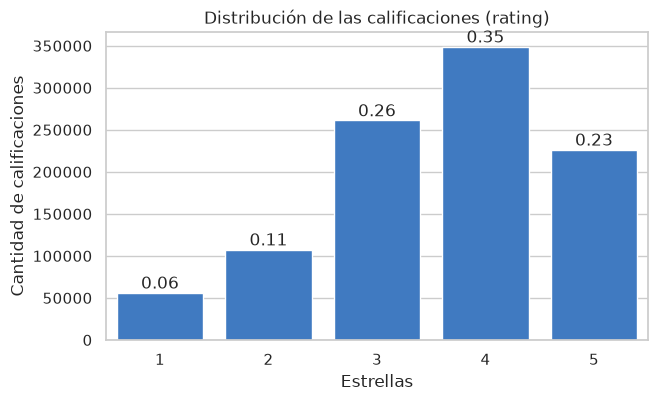

In [9]:
# gráfico de barras de la variable rating con su proporción
plt.figure(figsize=(7, 4))
ax = sns.countplot(x=df['rating'].astype(int), color=COLOR_GUSTA)
poner_proporciones(ax, float(len(df)))
plt.title('Distribución de las calificaciones (rating)')
plt.xlabel('Estrellas')
plt.ylabel('Cantidad de calificaciones')
plt.show()

In [10]:
# MÉTRICA PRINCIPAL
tasa_me_gusta = (df['rating'] >= ESTRELLAS_ME_GUSTA).mean()

print('Variable que calcula la métrica : rating')
print('Métrica principal               : Tasa de Me gusta (rating >= 4)')
print('Valor de la métrica             : {:.2%}'.format(tasa_me_gusta))

Variable que calcula la métrica : rating
Métrica principal               : Tasa de Me gusta (rating >= 4)
Valor de la métrica             : 57.52%


### 4.1.3. Pregunta 3 — Definir mi target

El target sale **directamente de la variable de la métrica (`rating`)**, así queda relacionado con la métrica principal:

| rating | le_gusta (target) | Significado |
|---|---|---|
| 1, 2, 3 | **0** | No me gusta |
| 4, 5 | **1** | Me gusta |

El promedio de `le_gusta` **es exactamente la métrica principal**.

In [11]:
# creamos el target
df['le_gusta'] = (df['rating'] >= ESTRELLAS_ME_GUSTA).astype(int)

# comprobamos que cada estrella cae en la clase correcta
pd.crosstab(df['rating'], df['le_gusta'])

le_gusta,0,1
rating,,
1.0,56174,0
2.0,107557,0
3.0,261197,0
4.0,0,348971
5.0,0,226310


In [12]:
df.le_gusta.unique()

array([1, 0])

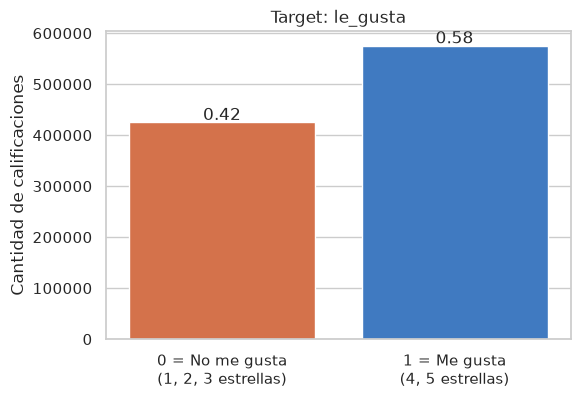

Promedio del target = 57.52%  (igual a la métrica principal)


In [13]:
# proporción de casos Me gusta / No me gusta
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='le_gusta', data=df, hue='le_gusta', palette=COLORES_TARGET, legend=False)
poner_proporciones(ax, float(len(df)))
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 = No me gusta\n(1, 2, 3 estrellas)', '1 = Me gusta\n(4, 5 estrellas)'])
plt.title('Target: le_gusta')
plt.xlabel('')
plt.ylabel('Cantidad de calificaciones')
plt.show()

print('Promedio del target = {:.2%}  (igual a la métrica principal)'.format(df['le_gusta'].mean()))

### 4.1.4. Pregunta 4 — Escoger las variables explicativas

Revisamos qué variables cambian la **tasa de Me gusta**. Si una variable no cambia la tasa, no ayuda a predecir.
La línea punteada es la tasa global.

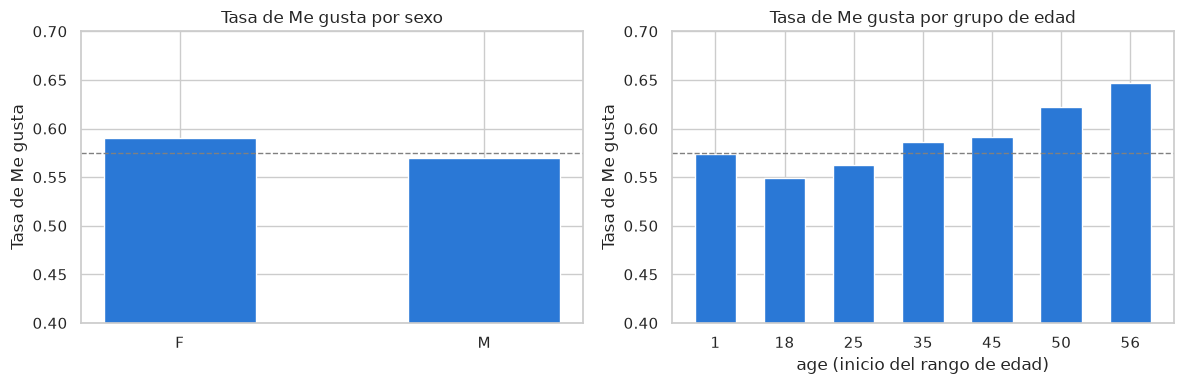

In [14]:
# tasa de Me gusta por sexo y por grupo de edad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tasa_sexo = df.groupby('gender')['le_gusta'].mean()
axes[0].bar(tasa_sexo.index, tasa_sexo.values, color=COLOR_GUSTA, width=0.5)
axes[0].set_title('Tasa de Me gusta por sexo')

tasa_edad = df.groupby('age')['le_gusta'].mean()
axes[1].bar(tasa_edad.index.astype(str), tasa_edad.values, color=COLOR_GUSTA, width=0.6)
axes[1].set_title('Tasa de Me gusta por grupo de edad')
axes[1].set_xlabel('age (inicio del rango de edad)')

for ax in axes:
    ax.axhline(tasa_me_gusta, color='gray', linestyle='--', linewidth=1)
    ax.set_ylim(0.4, 0.7)
    ax.set_ylabel('Tasa de Me gusta')
plt.tight_layout()
plt.show()

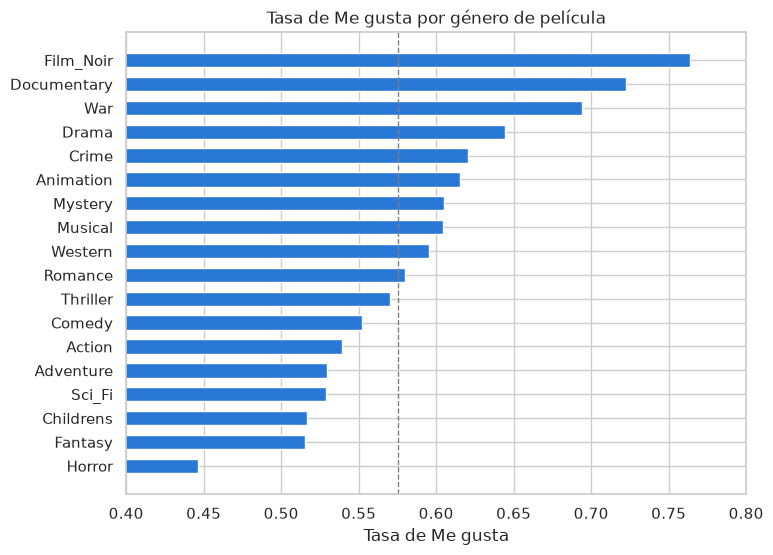

,calificaciones,tasa_me_gusta
genero_Horror,76386,0.446260
genero_Fantasy,36301,0.515523
genero_Childrens,72186,0.516416
genero_Sci_Fi,157294,0.528927
genero_Adventure,133953,0.529671
genero_Action,257457,0.538987
genero_Comedy,356580,0.552316
genero_Thriller,189680,0.570519
genero_Romance,147523,0.579564
genero_Western,20683,0.595223


In [15]:
# convertimos los géneros de la película a variables dummy (una película puede tener varios géneros)
generos = df['genres'].str.get_dummies(sep='|')
generos.columns = ['genero_' + c.replace("'", '').replace('-', '_') for c in generos.columns]

tasa_genero = pd.DataFrame({
    'calificaciones': generos.sum(),
    'tasa_me_gusta': [df.loc[generos[c] == 1, 'le_gusta'].mean() for c in generos.columns],
}).sort_values('tasa_me_gusta')

plt.figure(figsize=(8, 6))
plt.barh(tasa_genero.index.str.replace('genero_', ''), tasa_genero['tasa_me_gusta'], color=COLOR_GUSTA, height=0.6)
plt.axvline(tasa_me_gusta, color='gray', linestyle='--', linewidth=1)
plt.xlim(0.4, 0.8)
plt.title('Tasa de Me gusta por género de película')
plt.xlabel('Tasa de Me gusta')
plt.show()

tasa_genero

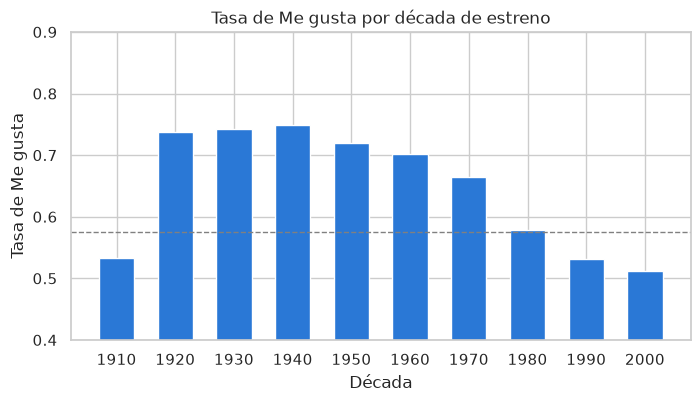

In [16]:
# tasa de Me gusta por década de estreno
df['decada_estreno'] = (df['anio_estreno'] // 10) * 10
tasa_decada = df.groupby('decada_estreno')['le_gusta'].mean()

plt.figure(figsize=(8, 4))
plt.bar(tasa_decada.index.astype(str), tasa_decada.values, color=COLOR_GUSTA, width=0.6)
plt.axhline(tasa_me_gusta, color='gray', linestyle='--', linewidth=1)
plt.ylim(0.4, 0.9)
plt.title('Tasa de Me gusta por década de estreno')
plt.xlabel('Década')
plt.ylabel('Tasa de Me gusta')
plt.show()

**Variables explicativas escogidas (primera iteración):**

| Grupo | Variable | Por qué |
|---|---|---|
| Usuario | `gender_M` (1 = hombre, 0 = mujer) | Las mujeres dan un poco más de Me gusta |
| Usuario | `age` | A más edad, mayor tasa de Me gusta |
| Película | `anio_estreno` | Las películas de 1920 a 1960 superan el 70% de Me gusta; las de los 90 y 2000 quedan por debajo de la tasa global |
| Película | `genero_*` (18 dummies) | Film-Noir, Documentary y War gustan más; Horror, Children's y Fantasy menos |
| Historial | `tasa_usuario` | Qué tan "generoso" es el usuario: su propia tasa de Me gusta |
| Historial | `tasa_pelicula` | Qué tan bien valorada está la película por los demás |

Las variables de **historial** se calculan **después de partir los datos y solo con train**, para que el modelo no haga trampa mirando el test (sección 4.1.5).

No se usan `userId`, `movieId`, `title`, `timestamp`, `fecha` ni `zip` porque son identificadores o texto, y `rating` porque es la respuesta (sería hacer trampa).

In [17]:
# variable dummy de sexo (igual que get_dummies del ejemplo de clase)
df['gender_M'] = (df['gender'] == 'M').astype(int)

# agregamos las dummies de género de película
df = pd.concat([df, generos.astype(int)], axis=1)

print(df.shape)
df.head(2)

(1000209, 34)


,userId,movieId,rating,timestamp,fecha,anio,title,genres,anio_estreno,gender,age,occupation,zip,le_gusta,decada_estreno,gender_M,genero_Action,genero_Adventure,genero_Animation,genero_Childrens,genero_Comedy,genero_Crime,genero_Documentary,genero_Drama,genero_Fantasy,genero_Film_Noir,genero_Horror,genero_Musical,genero_Mystery,genero_Romance,genero_Sci_Fi,genero_Thriller,genero_War,genero_Western
0,1,1193,5.0,978300760,2000-12-31 22:12:40,2000,One Flew Over the Cuckoo's Nest (1975),Drama,1975,F,1,10,48067,1,1970,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,1,661,3.0,978302109,2000-12-31 22:35:09,2000,James and the Giant Peach (1996),Animation|Children's|Musical,1996,F,1,10,48067,0,1990,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0


### 4.1.5. Pregunta 5 — Partición de datos en train y test

- **80% train / 20% test**, con `random_state=777` como en el ejemplo de clase.
- `stratify=y` mantiene la misma tasa de Me gusta en train y test.

In [18]:
# seleccionamos variables explicativas y variable dependiente
columnas_generos = list(generos.columns)
variables_base = ['gender_M', 'age', 'anio_estreno'] + columnas_generos

X = df[['userId', 'movieId'] + variables_base]   # userId y movieId solo para calcular el historial
y = df['le_gusta']                               # target variable

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

X_train = X_train.copy()
X_test = X_test.copy()

# tamaño de datos de entrenamiento
print('tamaño train', X_train.shape)
print('tamaño de test', X_test.shape)
print('tasa Me gusta train: {:.2%}'.format(y_train.mean()))
print('tasa Me gusta test : {:.2%}'.format(y_test.mean()))

tamaño train (800167, 23)
tamaño de test (200042, 23)
tasa Me gusta train: 57.52%
tasa Me gusta test : 57.52%


**Variables de historial (calculadas solo con train)**

Para cada usuario y cada película contamos, **en train**, cuántas calificaciones tiene (`n`) y cuántas fueron Me gusta (`s`).
Se mezcla con la tasa global usando `K_SUAVIZADO` votos ficticios, para que alguien con 1 solo voto no quede con tasa 0% o 100%:

$$\text{tasa} = \frac{s + K \cdot \text{tasa global}}{n + K}$$

- **En train** se resta la propia calificación de la fila (`s - y`, `n - 1`), así el modelo no ve su propia respuesta.
- **En test** se usan los conteos de train tal cual. Si el usuario o la película no aparece en train, recibe la tasa global.

In [19]:
tasa_global_train = y_train.mean()
entrenamiento = X_train[['userId', 'movieId']].assign(le_gusta=y_train)

for clave, nombre in [('userId', 'tasa_usuario'), ('movieId', 'tasa_pelicula')]:
    conteo = entrenamiento.groupby(clave)['le_gusta'].agg(n='count', s='sum')

    # train: sin contar la propia calificación
    n_tr = X_train[clave].map(conteo['n'])
    s_tr = X_train[clave].map(conteo['s'])
    X_train[nombre] = (s_tr - y_train + K_SUAVIZADO * tasa_global_train) / (n_tr - 1 + K_SUAVIZADO)

    # test: con lo aprendido en train
    n_te = X_test[clave].map(conteo['n']).fillna(0)
    s_te = X_test[clave].map(conteo['s']).fillna(0)
    X_test[nombre] = (s_te + K_SUAVIZADO * tasa_global_train) / (n_te + K_SUAVIZADO)

variables_explicativas = ['tasa_usuario', 'tasa_pelicula'] + variables_base
X_train = X_train[variables_explicativas]
X_test = X_test[variables_explicativas]

print('variables explicativas:', len(variables_explicativas))
X_train.head()

variables explicativas: 23


,tasa_usuario,tasa_pelicula,gender_M,age,anio_estreno,genero_Action,genero_Adventure,genero_Animation,genero_Childrens,genero_Comedy,genero_Crime,genero_Documentary,genero_Drama,genero_Fantasy,genero_Film_Noir,genero_Horror,genero_Musical,genero_Mystery,genero_Romance,genero_Sci_Fi,genero_Thriller,genero_War,genero_Western
471856,0.780255,0.827951,1,25,1987,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
632523,0.708180,0.809201,1,56,1995,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
20034,0.712297,0.651416,1,25,1994,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
71815,0.411926,0.137697,1,25,1997,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
440610,0.700846,0.775505,1,35,1989,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0


In [20]:
X_train[['tasa_usuario', 'tasa_pelicula', 'age', 'anio_estreno']].describe()

,tasa_usuario,tasa_pelicula,age,anio_estreno
count,800167.000000,800167.000000,800167.000000,800167.000000
mean,0.572225,0.578948,29.737549,1986.690895
std,0.162890,0.195655,11.754684,14.358987
min,0.080341,0.052287,1.000000,1919.000000
25%,0.461461,0.439802,25.000000,1982.000000
50%,0.585348,0.610460,25.000000,1992.000000
75%,0.694013,0.736355,35.000000,1997.000000
max,0.957516,0.930369,56.000000,2000.000000


## 4.2. MODELO
### Pregunta 6 — Entrenar el modelo

Regresión logística con `statsmodels` (`sm.Logit`), como en el ejemplo de clase.
Se agrega la **constante** (`sm.add_constant`) para que el modelo tenga intercepto.

In [21]:
# Ajusta el modelo de regresión logística
X_train_c = sm.add_constant(X_train)
X_test_c = sm.add_constant(X_test)

modelo_logit = sm.Logit(y_train, X_train_c).fit()

Optimization terminated successfully.
         Current function value: 0.551021
         Iterations 6


## 4.3. EVALUACIÓN

### 4.3.1. Resultados del Modelo

In [22]:
# Muestra un resumen del modelo
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:               le_gusta   No. Observations:               800167
Model:                          Logit   Df Residuals:                   800143
Method:                           MLE   Df Model:                           23
Date:                Wed, 16 Sep 2026   Pseudo R-squ.:                  0.1918
Time:                        17:37:05   Log-Likelihood:            -4.4091e+05
converged:                       True   LL-Null:                   -5.4556e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -3.0127      0.430     -7.008      0.000      -3.855      -2.170
tasa_usuario           4.2962      0.017    248.841      0.000       4.262       4.330
tasa_pelicula       

In [23]:
# coeficientes con su odds ratio: cuánto se multiplica la chance de "Me gusta" al subir la variable en 1
coeficientes = pd.DataFrame({
    'coef': modelo_logit.params,
    'odds_ratio': np.exp(modelo_logit.params),
    'p_valor': modelo_logit.pvalues,
})
coeficientes['significativa (p<0.05)'] = np.where(coeficientes['p_valor'] < 0.05, 'Sí', 'No')
coeficientes.sort_values('coef', ascending=False).round(4)

,coef,odds_ratio,p_valor,significativa (p<0.05)
tasa_pelicula,4.5609,95.6712,0.0000,Sí
tasa_usuario,4.2962,73.4182,0.0000,Sí
genero_Animation,0.0358,1.0364,0.0311,Sí
genero_Thriller,0.0356,1.0362,0.0000,Sí
genero_War,0.0282,1.0286,0.0133,Sí
gender_M,0.0245,1.0248,0.0001,Sí
genero_Documentary,0.0213,1.0215,0.4985,No
genero_Horror,0.0186,1.0188,0.0800,No
genero_Film_Noir,0.0181,1.0182,0.4249,No
genero_Crime,0.0121,1.0121,0.2355,No


**Principales métricas de clasificación desde la matriz de confusión**

- **TP** (Verdaderos Positivos): le gustó y el modelo dijo Me gusta.
- **TN** (Verdaderos Negativos): no le gustó y el modelo dijo No me gusta.
- **FP** (Falsos Positivos): no le gustó pero el modelo dijo Me gusta → *recomendamos una película mala*.
- **FN** (Falsos Negativos): le gustó pero el modelo dijo No me gusta → *dejamos de recomendar una buena*.

$$\text{Exactitud} = \frac{TP + TN}{TP + TN + FP + FN} \qquad \text{Precisión} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{\text{Precisión} \cdot \text{Recall}}{\text{Precisión} + \text{Recall}}$$

**AUC**: capacidad del modelo para separar Me gusta de No me gusta (0,5 = azar, 1 = perfecto).

**Línea base:** un modelo "tonto" que dice *Me gusta* a todo acierta la tasa global (~57,5%).
Nuestro modelo **tiene que superar esa exactitud** para servir de algo.

### 4.3.2. Pregunta 7 — Evaluación en datos de train

In [24]:
# predicción (probabilidad de Me gusta)
y_pred_train = modelo_logit.predict(X_train_c)
y_pred_train.head(10)

471856    0.917681
632523    0.866471
20034     0.785959
71815     0.092869
440610    0.859715
536033    0.553193
10953     0.944010
647472    0.536455
437711    0.924204
81222     0.189303
dtype: float64

In [25]:
# y_train: valores verdaderos ; y_pred_train: probabilidades predichas
metricas_train = metricas_clasificacion(y_train, y_pred_train, UMBRAL)
for nombre, valor in metricas_train.items():
    print('{:<10}: {:.4f}'.format(nombre, valor))

print('\nLínea base (decir Me gusta a todo): {:.4f}'.format(y_train.mean()))

Exactitud : 0.7190
Precisión : 0.7318
Recall    : 0.8071
F1-Score  : 0.7676
AUC       : 0.7813

Línea base (decir Me gusta a todo): 0.5752


In [26]:
print('Matriz de confusión (train):')
tabla_confusion(y_train, y_pred_train, UMBRAL)

Matriz de confusión (train):


,Modelo: No me gusta,Modelo: Me gusta
Real: No me gusta,203844,136098
Real: Me gusta,88779,371446


### 4.3.3. Pregunta 8 — Evaluación en datos de test

Estos datos **no se usaron para entrenar**: muestran cómo funcionará el modelo con calificaciones nuevas.

In [27]:
# Realiza predicciones en el conjunto de datos de prueba
y_pred = modelo_logit.predict(X_test_c)
y_pred.head(10)

156255    0.564496
404727    0.683845
53735     0.694074
326136    0.297006
490335    0.364166
278998    0.411221
304147    0.787459
195327    0.801149
351425    0.074185
480686    0.145528
dtype: float64

In [28]:
metricas_test = metricas_clasificacion(y_test, y_pred, UMBRAL)
for nombre, valor in metricas_test.items():
    print('{:<10}: {:.4f}'.format(nombre, valor))

print('\nLínea base (decir Me gusta a todo): {:.4f}'.format(y_test.mean()))

Exactitud : 0.7200
Precisión : 0.7323
Recall    : 0.8090
F1-Score  : 0.7687
AUC       : 0.7815

Línea base (decir Me gusta a todo): 0.5752


In [29]:
print('Matriz de confusión (test):')
tabla_confusion(y_test, y_pred, UMBRAL)

Matriz de confusión (test):


,Modelo: No me gusta,Modelo: Me gusta
Real: No me gusta,50957,34029
Real: Me gusta,21974,93082


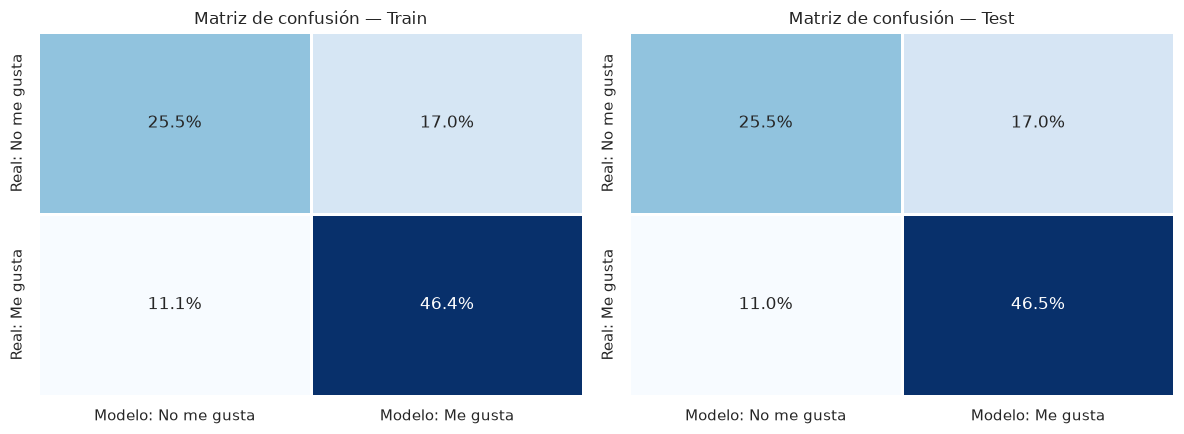

In [30]:
# matrices de confusión en porcentaje: train vs test
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (titulo, y_real, y_prob) in zip(axes, [('Train', y_train, y_pred_train), ('Test', y_test, y_pred)]):
    mc = tabla_confusion(y_real, y_prob, UMBRAL)
    sns.heatmap(mc / mc.values.sum(), annot=True, fmt='.1%', cmap='Blues', cbar=False, ax=ax,
                linewidths=2, linecolor='white')
    ax.set_title('Matriz de confusión — ' + titulo)
plt.tight_layout()
plt.show()

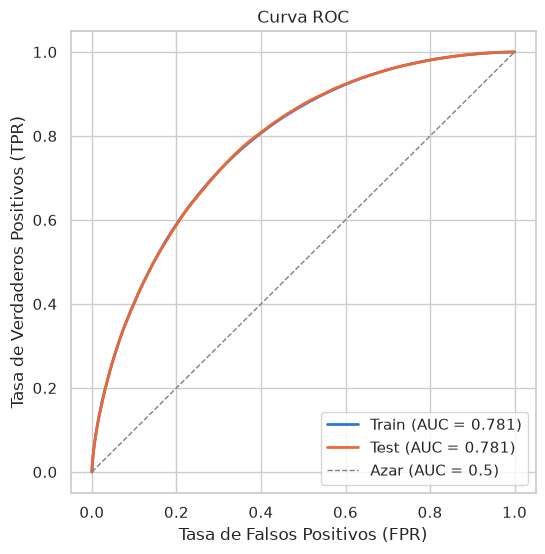

In [31]:
# curva ROC: train vs test
plt.figure(figsize=(6, 6))
for titulo, y_real, y_prob, color in [('Train', y_train, y_pred_train, COLOR_GUSTA),
                                      ('Test', y_test, y_pred, COLOR_NO_GUSTA)]:
    fpr, tpr, _ = roc_curve(y_real, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label='{} (AUC = {:.3f})'.format(titulo, roc_auc_score(y_real, y_prob)))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
plt.title('Curva ROC')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.show()

## 4.4. Pregunta 9 — Resultados del modelo de mi primera iteración

In [32]:
# resumen de métricas: línea base vs modelo en train y test
resultados = pd.DataFrame({
    'Línea base (todo Me gusta) - test': metricas_clasificacion(y_test, pd.Series(1.0, index=y_test.index), UMBRAL),
    'Modelo - train': metricas_train,
    'Modelo - test': metricas_test,
}).T
resultados['AUC'] = resultados['AUC'].where(resultados.index != 'Línea base (todo Me gusta) - test', 0.5)
resultados.round(4)

,Exactitud,Precisión,Recall,F1-Score,AUC
Línea base (todo Me gusta) - test,0.5752,0.5752,1.0000,0.7303,0.5000
Modelo - train,0.7190,0.7318,0.8071,0.7676,0.7813
Modelo - test,0.7200,0.7323,0.8090,0.7687,0.7815


In [33]:
# ¿cuánto mejora el modelo a la línea base en test?
exactitud_base = y_test.mean()
mejora = metricas_test['Exactitud'] - exactitud_base
print('Exactitud línea base : {:.2%}'.format(exactitud_base))
print('Exactitud modelo     : {:.2%}'.format(metricas_test['Exactitud']))
print('Mejora               : +{:.2f} puntos porcentuales'.format(mejora * 100))
print('Diferencia train-test: {:.4f}  (si es pequeña, no hay sobreajuste)'.format(
    metricas_train['Exactitud'] - metricas_test['Exactitud']))

Exactitud línea base : 57.52%
Exactitud modelo     : 72.00%
Mejora               : +14.49 puntos porcentuales
Diferencia train-test: -0.0011  (si es pequeña, no hay sobreajuste)


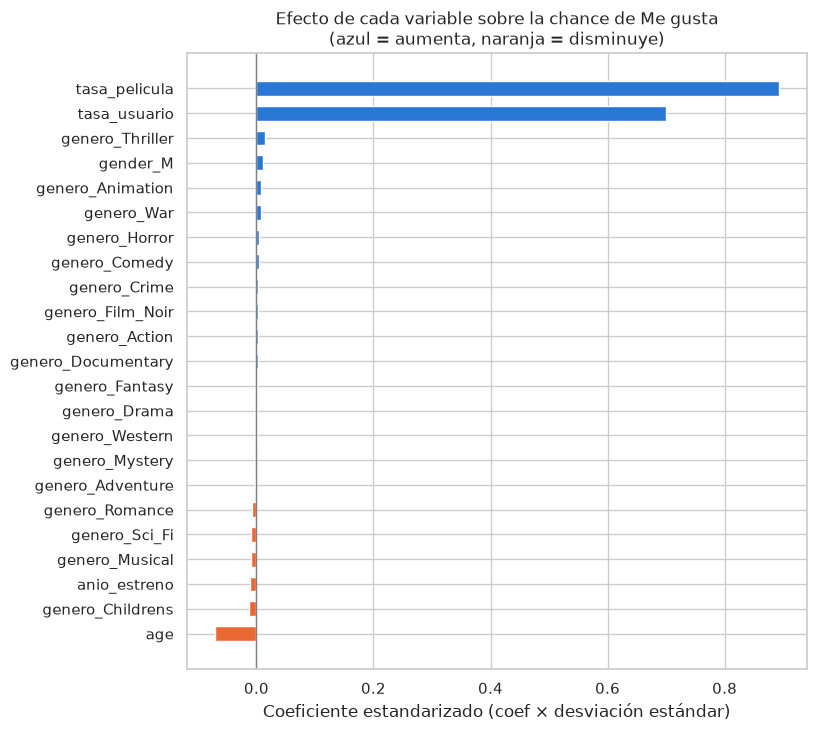

In [34]:
# peso de cada variable: coeficiente estandarizado (coef * desviación estándar de la variable)
importancia = (modelo_logit.params.drop('const') * X_train.std()).sort_values()

plt.figure(figsize=(8, 8))
colores = [COLOR_GUSTA if v > 0 else COLOR_NO_GUSTA for v in importancia]
plt.barh(importancia.index, importancia.values, color=colores, height=0.6)
plt.axvline(0, color='gray', linewidth=1)
plt.title('Efecto de cada variable sobre la chance de Me gusta\n(azul = aumenta, naranja = disminuye)')
plt.xlabel('Coeficiente estandarizado (coef × desviación estándar)')
plt.show()

### Respuestas a las 9 preguntas — Primera iteración

| # | Pregunta | Respuesta |
|---|---|---|
| 1 | Métrica y su valor | **Tasa de Me gusta = 57,52%** de las 1.000.209 calificaciones |
| 2 | Variable que calcula la métrica | **`rating`** (1 a 5 estrellas) |
| 3 | Target | **`le_gusta`**: 1 = Me gusta (4 y 5 estrellas), 0 = No me gusta (1, 2 y 3 estrellas). Su promedio es la métrica |
| 4 | Variables explicativas | 23 variables: `tasa_usuario`, `tasa_pelicula`, `gender_M`, `age`, `anio_estreno` y 18 dummies de género |
| 5 | Partición | 80% train (800.167) / 20% test (200.042), `random_state=777`, estratificada (57,52% de Me gusta en ambos) |
| 6 | Entrenamiento | `sm.Logit` con constante; convergió en 6 iteraciones; Pseudo R² = 0,19; LLR p-valor = 0,000 (el modelo sí es significativo) |
| 7 | Evaluación train | Exactitud **71,90%** · Precisión 73,18% · Recall 80,71% · F1 76,76% · AUC 0,781 |
| 8 | Evaluación test | Exactitud **72,00%** · Precisión 73,23% · Recall 80,90% · F1 76,87% · AUC 0,782 |
| 9 | Resultado | El modelo **mejora en +14,5 puntos** la línea base (57,52% → 72,00%) y **no está sobreajustado** (train y test prácticamente iguales) |

### Interpretación

**Matriz de confusión en test (200.042 calificaciones):**

| | Modelo: No me gusta | Modelo: Me gusta |
|---|---|---|
| **Real: No me gusta** | 50.957 (TN, bien) | 34.029 (FP, mal) |
| **Real: Me gusta** | 21.974 (FN, mal) | 93.082 (TP, bien) |

- De cada 100 películas que el modelo marca como **Me gusta**, **73 le gustan de verdad** (precisión).
- De cada 100 películas que **sí le gustan** al usuario, el modelo **encuentra 81** (recall).
- El error más frecuente son los **falsos positivos** (17% de los casos): películas que el modelo cree que gustarán y reciben 3 estrellas o menos.

**¿Qué variables importan?**

1. **`tasa_pelicula`** (coef 4,56) y **`tasa_usuario`** (coef 4,30) son, por lejos, las más fuertes.
   Si una película o un usuario tiene historial de Me gusta, la probabilidad sube mucho.
   Esto confirma la idea del **filtrado colaborativo** del proyecto: el historial vale más que los datos demográficos.
2. **`age`** (coef −0,006) y **`anio_estreno`** (coef −0,0008) son significativas pero de efecto pequeño.
   Solas parecían importantes (los mayores y las películas antiguas dan más Me gusta), pero ese efecto **ya lo captan las tasas de historial**.
3. **`gender_M`** es significativa pero con efecto muy pequeño (odds ratio 1,02).
4. **Géneros:** una vez que se conoce la tasa de la película, casi no aportan. Solo 8 de 18 son significativos y todos con odds ratio entre 0,95 y 1,04.
   Children's, Musical, Sci-Fi y Romance bajan un poco la chance; Thriller, Animation y War la suben un poco.

### Conclusión de la primera iteración

- Con regresión logística podemos predecir si a un usuario **le gustará o no** una película con **72% de exactitud** y **AUC de 0,78**, bastante mejor que decir "Me gusta" a todo (57,52%).
- El resultado es **estable**: en test se obtiene lo mismo que en train, así que el modelo generaliza.
- Casi todo el poder predictivo viene del **historial** (usuario y película); las variables demográficas y los géneros aportan muy poco.

### Próximos pasos (segunda iteración)

- Quitar los géneros y variables no significativas y comparar si el modelo pierde exactitud (modelo más simple).
- Probar otras variables: `occupation`, cantidad de votos de la película (popularidad), afinidad del usuario con cada género.
- Ajustar el **umbral** (0,5): subirlo reduce los falsos positivos (recomendar películas malas) a costa de recall.